In [1]:
import joblib
import json
import pandas as pd

model = joblib.load("fraud_model.pkl")

with open("features.json", "r") as f:
    features = json.load(f)

# Load dataset (same one used in training)
df = pd.read_csv("C:/Users/gaura/Downloads/featured_fraud_data.csv")

X = df[features]

In [2]:
!pip install shap
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

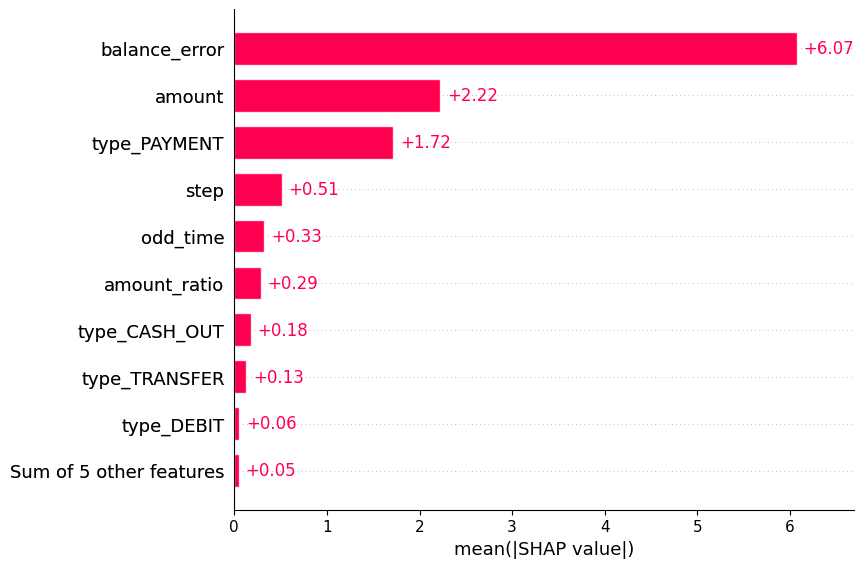

In [4]:
shap.plots.bar(shap_values)

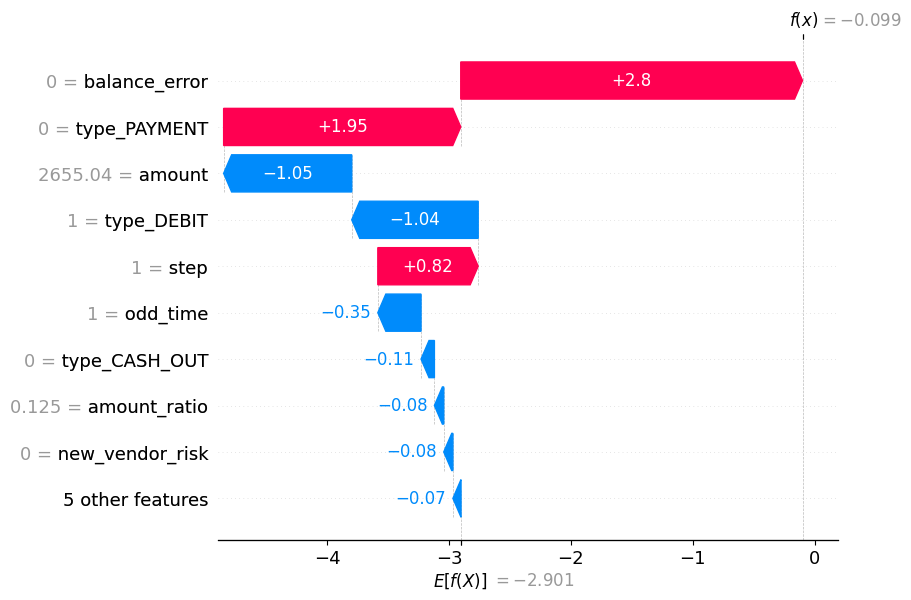

In [5]:
shap.plots.waterfall(shap_values[0])

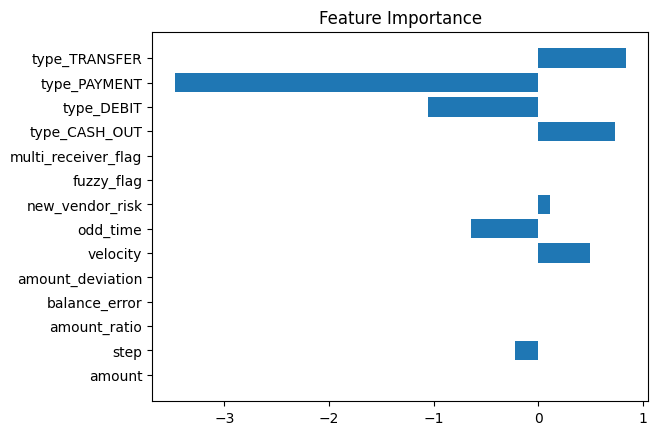

In [6]:
import matplotlib.pyplot as plt

importance = model.coef_[0]

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [7]:
shap_df = pd.DataFrame(shap_values.values, columns=features)
shap_df.to_csv("shap_values.csv", index=False)

In [8]:
import pandas as pd

df = pd.read_csv("C:/Users/gaura/Downloads/featured_fraud_data.csv")